# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O CIFAR-10 é uma base de dados utilizada principalmente na área de visão computacional e aprendizado de máquina, especialmente em tarefas de classificação de imagens. Ela foi criada para servir como referência no treinamento e teste de modelos capazes de reconhecer automaticamente objetos em imagens. O conjunto contém 60.000 imagens coloridas, com resolução de 32x32 pixels, divididas em 10 classes, sendo 50.000 imagens para treinamento e 10.000 para teste. Cada classe possui 6.000 imagens, e os objetos representados incluem avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio e caminhão. Por conter imagens pequenas, variadas e rotuladas, o CIFAR-10 é bastante usado para avaliar algoritmos de redes neurais e outros modelos de classificação visual.

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [4]:
print("Dimensões dos conjuntos de imagens:")
print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)

print("\nFormato de uma imagem:")
print(x_train[0].shape)

print("\nDimensões dos vetores de rótulos:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nValores únicos da variável alvo:")
print("Treino:", np.unique(y_train))
print("Validação:", np.unique(y_val))
print("Teste:", np.unique(y_test))

print("\nQuantidade de classes:")
print(len(np.unique(y_train)))

Dimensões dos conjuntos de imagens:
x_train: (40000, 32, 32, 3)
x_val: (10000, 32, 32, 3)
x_test: (10000, 32, 32, 3)

Formato de uma imagem:
(32, 32, 3)

Dimensões dos vetores de rótulos:
y_train: (40000,)
y_val: (10000,)
y_test: (10000,)

Valores únicos da variável alvo:
Treino: [0 1 2 3 4 5 6 7 8 9]
Validação: [0 1 2 3 4 5 6 7 8 9]
Teste: [0 1 2 3 4 5 6 7 8 9]

Quantidade de classes:
10


Com base na saída obtida, o conjunto de treinamento possui 40.000 imagens, o de validação possui 10.000 imagens e o de teste possui 10.000 imagens. Cada imagem possui resolução de 32x32 pixels e 3 canais de cor, indicando que são imagens coloridas no padrão RGB. Os vetores de rótulos possuem uma classe associada a cada imagem, com dimensões compatíveis com seus respectivos conjuntos. Os valores únicos da variável alvo vão de 0 a 9, totalizando 10 classes diferentes no dataset.


### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

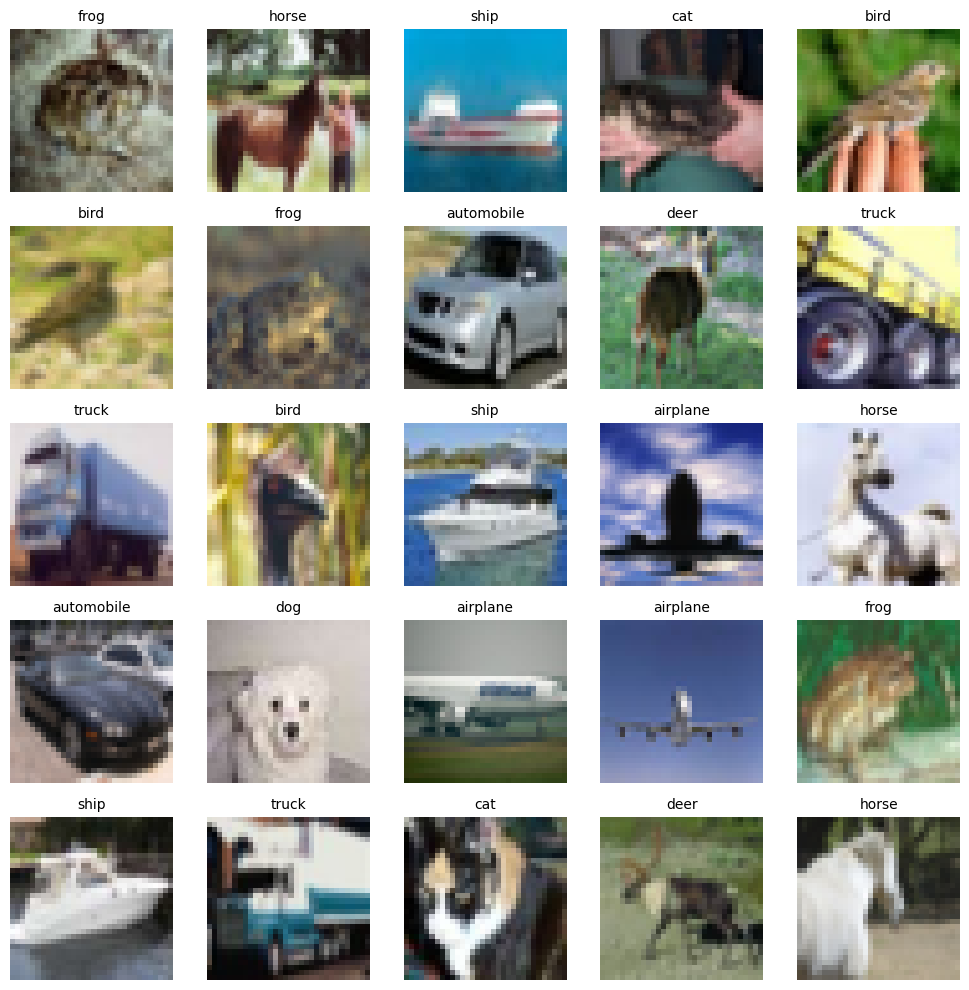

In [5]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Analisando as imagens do CIFAR-10, é possível perceber que a tarefa de classificação não é trivial, mesmo com apenas 10 classes. A principal limitação está na resolução reduzida de 32x32 pixels, que preserva pouquíssima informação visual e dificulta a identificação de detalhes finos dos objetos.
Além disso, as imagens apresentam grande variabilidade nas condições de captura: fundos distintos, ângulos variados, iluminação irregular e objetos por vezes pequenos ou parcialmente desfocados na cena. Isso exige que o modelo aprenda representações mais abstratas, sem depender de características visuais muito específicas.
Outro fator relevante é a semelhança visual entre determinadas classes. Automobile e truck compartilham estrutura e forma por serem veículos terrestres. Cat, dog, deer e horse possuem silhuetas e texturas similares. Já airplane e ship podem se confundir em imagens com fundo predominantemente azul ou em perspectivas pouco convencionais. Esses casos de ambiguidade representam um desafio real para o classificador, pois as fronteiras entre classes não são sempre bem definidas visualmente.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

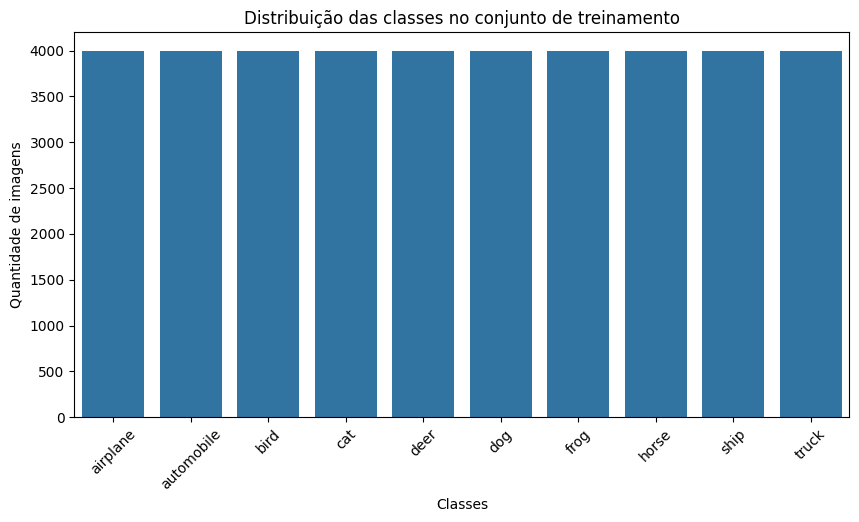

airplane: 4000
automobile: 4000
bird: 4000
cat: 4000
deer: 4000
dog: 4000
frog: 4000
horse: 4000
ship: 4000
truck: 4000


In [6]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=class_counts)

plt.title("Distribuição das classes no conjunto de treinamento")
plt.xlabel("Classes")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=45)
plt.show()

for classe, quantidade in zip(class_names, class_counts):
    print(f"{classe}: {quantidade}")

Com base no gráfico e nas quantidades exibidas, o conjunto de treinamento está balanceado, pois todas as 10 classes possuem exatamente 4.000 imagens cada. Isso significa que não há uma classe com quantidade muito maior ou menor de amostras em relação às demais. Esse balanceamento é positivo para o treinamento de uma rede neural, pois evita que o modelo aprenda a favorecer classes mais frequentes. Em datasets desbalanceados, a rede pode apresentar bom desempenho aparente, mas classificar mal as classes com poucas amostras. Neste caso, como todas as classes têm a mesma quantidade de imagens, o modelo tende a receber exemplos igualmente distribuídos de cada categoria, favorecendo um aprendizado mais justo entre as classes.


### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [7]:
print("Antes da normalização:")
print("x_train - mínimo:", x_train.min(), "máximo:", x_train.max())
print("x_val   - mínimo:", x_val.min(), "máximo:", x_val.max())
print("x_test  - mínimo:", x_test.min(), "máximo:", x_test.max())

# Normalização dos pixels para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("\nDepois da normalização:")
print("x_train - mínimo:", x_train.min(), "máximo:", x_train.max())
print("x_val   - mínimo:", x_val.min(), "máximo:", x_val.max())
print("x_test  - mínimo:", x_test.min(), "máximo:", x_test.max())

Antes da normalização:
x_train - mínimo: 0 máximo: 255
x_val   - mínimo: 0 máximo: 255
x_test  - mínimo: 0 máximo: 255

Depois da normalização:
x_train - mínimo: 0.0 máximo: 1.0
x_val   - mínimo: 0.0 máximo: 1.0
x_test  - mínimo: 0.0 máximo: 1.0


Antes da normalização, os pixels das imagens estavam no intervalo de 0 a 255, que é o formato comum de imagens RGB. Após dividir os valores por 255, os dados passaram para o intervalo de 0.0 a 1.0. Esse procedimento é importante para o treinamento de redes neurais profundas porque coloca os valores de entrada em uma escala menor e padronizada, facilitando o aprendizado dos pesos da rede. Quando os valores de entrada são muito altos, os cálculos internos podem ficar menos estáveis e dificultar o ajuste dos parâmetros durante o treinamento. Com a normalização, o algoritmo de otimização trabalha com números menores, o que melhora a estabilidade numérica, reduz oscilações no cálculo dos gradientes e geralmente permite que o modelo convirja mais rapidamente. Dessa forma, a rede tende a aprender de maneira mais eficiente e estável.


### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

As imagens do CIFAR-10 podem ser representadas como tensores tridimensionais porque cada imagem possui informações distribuídas em três dimensões: altura, largura e canais de cor. No formato (32, 32, 3), o primeiro valor 32 representa a altura da imagem em pixels, o segundo 32 representa a largura, e o valor 3 representa os três canais de cor do padrão RGB: vermelho, verde e azul. Cada pixel da imagem é formado pela combinação desses três canais, permitindo representar imagens coloridas. Em redes neurais convolucionais, essa estrutura é importante porque os filtros convolucionais analisam padrões espaciais, como bordas, formas e texturas, considerando também as informações de cor. Já imagens em tons de cinza possuem apenas um canal, geralmente representadas como (altura, largura, 1), pois cada pixel contém somente a intensidade luminosa. Assim, imagens coloridas fornecem mais informações para a rede, mas também exigem mais parâmetros e processamento do que imagens em tons de cinza.


# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [9]:
model_mlp = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])


### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [10]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

A tabela mostra que MLPs podem se tornar modelos muito grandes em problemas de classificação de imagens, porque as camadas densas conectam cada entrada a todos os neurônios da próxima camada. Mesmo com imagens pequenas, como as do CIFAR-10, o vetor de entrada já possui 3072 características. Se as imagens tivessem maior resolução, esse número cresceria rapidamente, aumentando muito a quantidade de pesos a serem treinados. Por isso, MLPs exigem mais memória, mais processamento e podem ter maior risco de overfitting em tarefas de visão computacional, principalmente quando comparadas às redes convolucionais, que aproveitam melhor a estrutura espacial das imagens.


### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [11]:
model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

A função de custo tem o papel de medir o erro entre a saída prevista pela rede neural e o rótulo real de cada imagem. Durante o treinamento, o objetivo é reduzir esse erro ao longo das épocas, fazendo com que o modelo ajuste seus pesos para produzir previsões mais próximas das classes corretas. O otimizador Adam é o algoritmo responsável por atualizar os pesos da rede com base nos gradientes calculados a partir da função de custo, buscando minimizar essa perda de forma eficiente. A combinação entre **Softmax** e **entropia cruzada** é adequada para classificação multiclasse porque a Softmax transforma a saída da rede em probabilidades para cada uma das 10 classes, enquanto a entropia cruzada penaliza previsões incorretas, principalmente quando o modelo atribui alta probabilidade à classe errada. Como os rótulos do CIFAR-10 estão representados como inteiros de 0 a 9, a função `sparse_categorical_crossentropy` é apropriada, pois não exige converter os rótulos para o formato one-hot.


### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

In [12]:
history_mlp = model_mlp.fit(
    x_train,
    y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3140 - loss: 1.9075 - val_accuracy: 0.3769 - val_loss: 1.7418
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3920 - loss: 1.6939 - val_accuracy: 0.4181 - val_loss: 1.6407
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4247 - loss: 1.6095 - val_accuracy: 0.4323 - val_loss: 1.6237
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4450 - loss: 1.5510 - val_accuracy: 0.4505 - val_loss: 1.5728
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4631 - loss: 1.5050 - val_accuracy: 0.4485 - val_loss: 1.5551
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4764 - loss: 1.4660 - val_accuracy: 0.4641 - val_loss: 1.5167
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4868 - loss: 1.4347 - val_accuracy: 0.4690 - val_loss: 1.5088
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4955 - loss: 1.4089 - val_accuracy: 0.

A rede aparenta convergir no conjunto de treinamento, mas não de forma ideal no conjunto de validação. O treinamento fica relativamente estável no início, mas depois há uma separação crescente entre as curvas de treino e validação. Esse comportamento indica que a MLP está memorizando características específicas do conjunto de treinamento, em vez de aprender padrões mais gerais. Isso é esperado pois MLPs não aproveitam bem a estrutura espacial das imagens.


### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [14]:
test_loss_mlp, test_accuracy_mlp = model_mlp.evaluate(x_test, y_test)

print("Resultados da MLP no conjunto de teste:")
print(f"Loss de teste: {test_loss_mlp:.4f}")
print(f"Accuracy de teste: {test_accuracy_mlp:.4f}")

print("\nResultados finais no conjunto de treinamento:")
print(f"Loss de treino: {history_mlp.history['loss'][-1]:.4f}")
print(f"Accuracy de treino: {history_mlp.history['accuracy'][-1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4576 - loss: 1.6283
Resultados da MLP no conjunto de teste:
Loss de teste: 1.6283
Accuracy de teste: 0.4576

Resultados finais no conjunto de treinamento:
Loss de treino: 1.1609
Accuracy de treino: 0.5856


Comparando o desempenho em cada um dos conjuntos percebe-se que o desempenho no treino foi melhor do que no teste.
Essa diferença indica que o modelo não apresenta uma capacidade de generalização muito boa. A rede conseguiu aprender melhor os padrões das imagens usadas no treinamento, mas teve mais dificuldade para classificar corretamente imagens novas do conjunto de teste. Como a acurácia de teste ficou próxima da acurácia de validação observada anteriormente e bem abaixo da acurácia de treino, há indícios de overfitting. Portanto, a MLP aprendeu parcialmente o problema, mas não generalizou de forma tão eficiente para dados não vistos.

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step


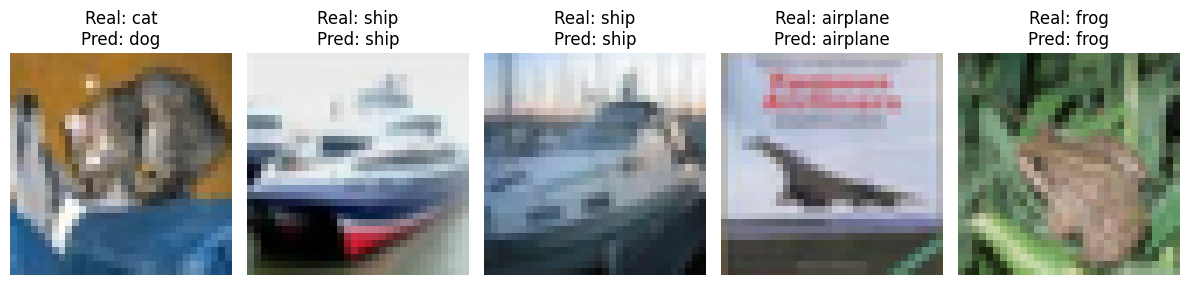


Imagem 1
Classe verdadeira: cat
Classe predita: dog
Probabilidades por classe:
airplane: 0.2810
automobile: 0.0097
bird: 0.0173
cat: 0.0567
deer: 0.0380
dog: 0.5580
frog: 0.0039
horse: 0.0028
ship: 0.0219
truck: 0.0107

Imagem 2
Classe verdadeira: ship
Classe predita: ship
Probabilidades por classe:
airplane: 0.1497
automobile: 0.0238
bird: 0.0017
cat: 0.0001
deer: 0.0002
dog: 0.0002
frog: 0.0000
horse: 0.0010
ship: 0.5222
truck: 0.3010

Imagem 3
Classe verdadeira: ship
Classe predita: ship
Probabilidades por classe:
airplane: 0.1557
automobile: 0.0115
bird: 0.0010
cat: 0.0001
deer: 0.0001
dog: 0.0001
frog: 0.0000
horse: 0.0007
ship: 0.8100
truck: 0.0208

Imagem 4
Classe verdadeira: airplane
Classe predita: airplane
Probabilidades por classe:
airplane: 0.4635
automobile: 0.0079
bird: 0.0349
cat: 0.0298
deer: 0.0185
dog: 0.0102
frog: 0.0002
horse: 0.0786
ship: 0.2955
truck: 0.0609

Imagem 5
Classe verdadeira: frog
Classe predita: frog
Probabilidades por classe:
airplane: 0.0005
automob

In [15]:
# Selecionando algumas imagens do conjunto de teste
num_imagens = 5
imagens_teste = x_test[:num_imagens]
rotulos_verdadeiros = y_test[:num_imagens]

# Gerando previsões
probabilidades = model_mlp.predict(imagens_teste)
classes_preditas = np.argmax(probabilidades, axis=1)

# Exibindo imagens com classe verdadeira e predita
plt.figure(figsize=(12, 4))

for i in range(num_imagens):
    plt.subplot(1, num_imagens, i + 1)
    plt.imshow(imagens_teste[i])
    plt.title(
        f"Real: {class_names[rotulos_verdadeiros[i]]}\n"
        f"Pred: {class_names[classes_preditas[i]]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# Exibindo probabilidades para cada classe
for i in range(num_imagens):
    print(f"\nImagem {i + 1}")
    print(f"Classe verdadeira: {class_names[rotulos_verdadeiros[i]]}")
    print(f"Classe predita: {class_names[classes_preditas[i]]}")
    print("Probabilidades por classe:")

    for nome_classe, prob in zip(class_names, probabilidades[i]):
        print(f"{nome_classe}: {prob:.4f}")

A saída Softmax mostra a probabilidade atribuída pelo modelo para cada uma das 10 classes, sendo escolhida como predição a classe com maior valor. Nas imagens analisadas, a MLP acertou 4 de 5 previsões, errando apenas a imagem da classe cat, que foi classificada como dog. Em geral, o modelo apresentou confiança moderada, pois algumas previsões corretas tiveram probabilidades próximas de 0,50, indicando certa dúvida entre classes semelhantes. A previsão mais confiante foi para ship, com probabilidade de 0,8100.


### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


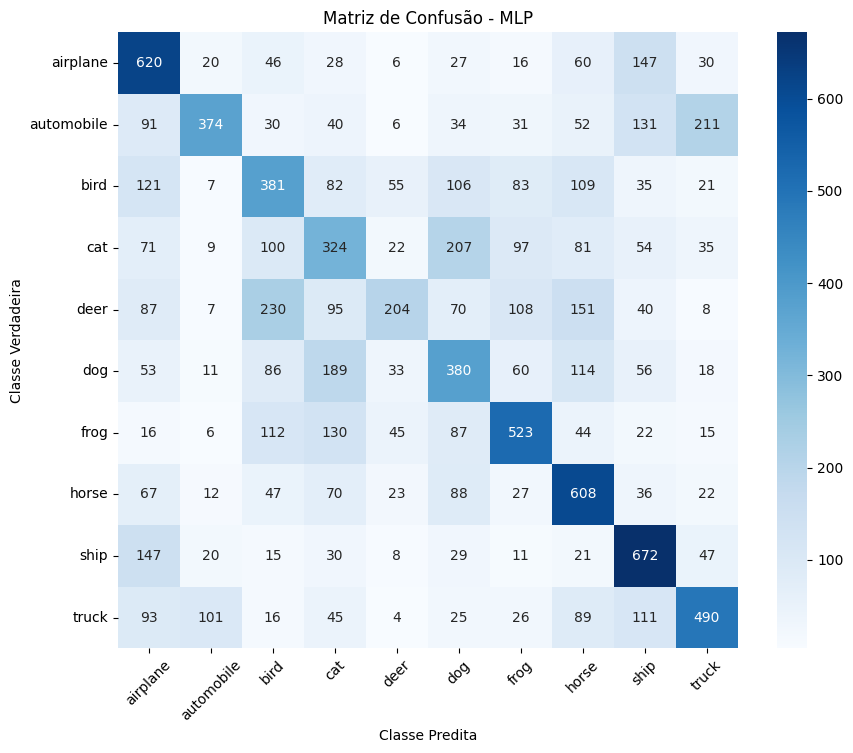

In [16]:
# Gerando previsões para todo o conjunto de teste
y_pred_probs_mlp = model_mlp.predict(x_test)
y_pred_mlp = np.argmax(y_pred_probs_mlp, axis=1)

# Matriz de confusão
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de Confusão - MLP")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

A matriz mostra que a MLP classificou melhor classes como ship, airplane, horse e frog. As maiores confusões ocorreram entre classes parecidas, como cat e dog automobile e truck, além de várias classes de animais, como bird, deer, cat, dog e horse. Esses erros acontecem porque a MLP usa a camada Flatten, que transforma a imagem em vetor e perde a estrutura espacial dos pixels, dificultando a identificação de formas, bordas e texturas importantes para classificação de imagens.


### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

As redes MLP têm como vantagem a simplicidade de implementação e entendimento, pois utilizam camadas densas e conseguem aprender alguns padrões das imagens. No CIFAR-10, a MLP obteve certo aprendizado porém, suas limitações ficaram evidentes, ao usar a camada Flatten, a imagem é transformada em um vetor, fazendo com que a estrutura espacial dos pixels seja perdida, isso dificulta a identificação de bordas, formas, texturas e relações locais importantes para visão computacional, além disso, mesmo com imagens pequenas, a rede teve mais de 1,7 milhão de parâmetros treináveis, o que aumenta o custo computacional e o risco de overfitting. A diferença entre o desempenho de treino e teste indica que o modelo não generalizou muito bem. Portanto, embora MLPs possam ser usadas para classificação de imagens, elas não são a arquitetura mais adequada para esse tipo de problema.


# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

As arquiteturas MLP apresentam limitações em problemas de visão computacional porque transformam a imagem em um vetor unidimensional por meio da camada Flatten. Com isso, a organização espacial original dos pixels é perdida, ou seja, a rede não considera diretamente quais pixels estão próximos uns dos outros. Essa perda dificulta o reconhecimento de padrões visuais importantes, como bordas, formas, texturas e partes de objetos. Além disso, como as camadas densas conectam todos os pixels a todos os neurônios, a quantidade de parâmetros cresce rapidamente, aumentando o custo computacional e o risco de overfitting.

As CNNs lidam melhor com imagens porque preservam a estrutura espacial dos dados. Em vez de analisar a imagem inteira como um vetor, elas aplicam filtros em pequenas regiões da imagem, mantendo a relação de vizinhança entre os pixels. A convolução é a operação em que um filtro percorre a imagem, realizando cálculos locais para detectar padrões específicos. Os filtros convolucionais são pequenas matrizes de pesos aprendidas durante o treinamento, capazes de identificar características como bordas, curvas, texturas ou formas. O resultado da aplicação desses filtros são os mapas de características, ou feature maps, que indicam onde determinados padrões foram encontrados na imagem. Dessa forma, as CNNs conseguem aprender representações visuais de forma mais eficiente que as MLPs.


### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [17]:
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


As camadas convolucionais têm o papel de extrair características das imagens, como bordas, texturas, formas e padrões visuais. Elas fazem isso aplicando filtros em pequenas regiões da imagem, preservando a relação espacial entre os pixels. As camadas MaxPooling2D reduzem as dimensões dos mapas de características, mantendo as informações mais importantes e diminuindo o custo computacional. Além disso, o pooling ajuda a tornar a rede menos sensível a pequenas variações na posição dos objetos. A camada Flatten transforma os mapas de características finais em um vetor unidimensional, permitindo que essas informações sejam usadas pelas camadas finais da rede para realizar a classificação. A camada de saída possui 10 neurônios com ativação Softmax, representando as probabilidades de cada uma das 10 classes do CIFAR-10.


### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [18]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,738 (444.29 KB)

 Trainable params: 113,738 (444.29 KB)

 Non-trainable params: 0 (0.00 B)

A CNN possui 113.738 parâmetros treináveis, enquanto a MLP tinha 1.707.274. Mesmo com menos parâmetros, a CNN é mais eficiente para imagens porque usa filtros convolucionais que analisam pequenas regiões da imagem e compartilham pesos, reduzindo o custo computacional. Além disso, ela preserva melhor a estrutura espacial dos pixels, permitindo identificar bordas, texturas e formas. Por isso, CNNs tendem a generalizar melhor que MLPs em tarefas de classificação de imagens.


### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

In [19]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    x_train,
    y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.4503 - loss: 1.5219 - val_accuracy: 0.5644 - val_loss: 1.2346
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6152 - loss: 1.0998 - val_accuracy: 0.6403 - val_loss: 1.0378
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6802 - loss: 0.9234 - val_accuracy: 0.6738 - val_loss: 0.9412
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7182 - loss: 0.8181 - val_accuracy: 0.6984 - val_loss: 0.8870
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7474 - loss: 0.7364 - val_accuracy: 0.7104 - val_loss: 0.8597
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7703 - loss: 0.6694 - val_accuracy: 0.7077 - val_loss: 0.8817
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7870 - loss: 0.6199 - val_accuracy: 0.7120 - val_loss: 0.8786
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8044 - loss: 0.5716 - val_accuracy: 

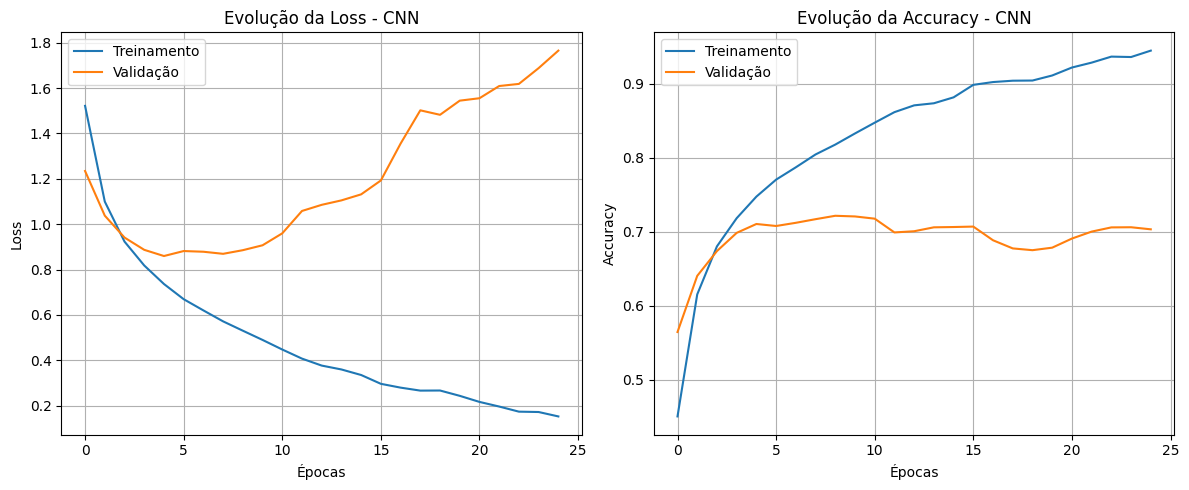

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Treinamento')
plt.plot(history_cnn.history['val_loss'], label='Validação')
plt.title('Evolução da Loss - CNN')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Treinamento')
plt.plot(history_cnn.history['val_accuracy'], label='Validação')
plt.title('Evolução da Accuracy - CNN')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

A CNN apresentou um desempenho melhor que a MLP, mostrando que conseguiu aprender melhor os padrões das imagens. No início do treinamento, a perda diminui e a acurácia aumenta tanto no treino quanto na validação, indicando boa evolução do modelo. Porém, depois de algumas épocas, a rede começa a apresentar sinais de overfitting. Mesmo assim, a CNN se mostrou mais adequada para classificação de imagens, pois consegue aproveitar melhor a estrutura espacial dos pixels.


### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [21]:
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(x_test, y_test)

print("Resultados da CNN no conjunto de teste:")
print(f"Loss de teste: {test_loss_cnn:.4f}")
print(f"Accuracy de teste: {test_accuracy_cnn:.4f}")

print("\nResultados da MLP no conjunto de teste:")
print(f"Loss de teste: {test_loss_mlp:.4f}")
print(f"Accuracy de teste: {test_accuracy_mlp:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7032 - loss: 1.7997
Resultados da CNN no conjunto de teste:
Loss de teste: 1.7997
Accuracy de teste: 0.7032

Resultados da MLP no conjunto de teste:
Loss de teste: 1.6283
Accuracy de teste: 0.4576


A CNN apresentou desempenho superior à MLP no conjunto de teste, principalmente em termos de acurácia. Isso indica que ela conseguiu generalizar melhor para imagens que não foram usadas no treinamento.

A principal diferença está na forma como cada arquitetura trabalha com as imagens. A MLP transforma a imagem em um vetor, perdendo a relação espacial entre os pixels. Já a CNN preserva essa estrutura e consegue aprender características visuais locais, como bordas, texturas e formas. Por isso, mesmo apresentando alguns sinais de overfitting durante o treinamento, a CNN foi mais adequada para a classificação das imagens.


### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step


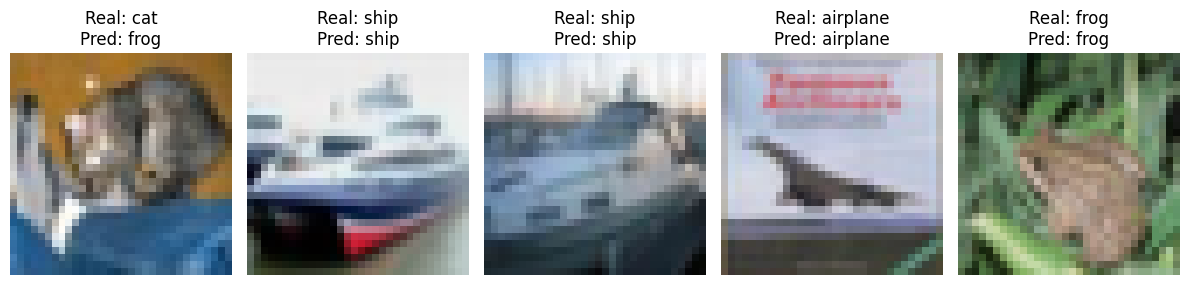


Imagem 1
Classe verdadeira: cat
Classe predita: frog
Probabilidades por classe:
airplane: 0.0000
automobile: 0.0169
bird: 0.0000
cat: 0.1250
deer: 0.0000
dog: 0.1791
frog: 0.6198
horse: 0.0000
ship: 0.0591
truck: 0.0000

Imagem 2
Classe verdadeira: ship
Classe predita: ship
Probabilidades por classe:
airplane: 0.0000
automobile: 0.0000
bird: 0.0000
cat: 0.0000
deer: 0.0000
dog: 0.0000
frog: 0.0000
horse: 0.0000
ship: 1.0000
truck: 0.0000

Imagem 3
Classe verdadeira: ship
Classe predita: ship
Probabilidades por classe:
airplane: 0.0670
automobile: 0.0018
bird: 0.0000
cat: 0.0000
deer: 0.0000
dog: 0.0000
frog: 0.0000
horse: 0.0000
ship: 0.8826
truck: 0.0486

Imagem 4
Classe verdadeira: airplane
Classe predita: airplane
Probabilidades por classe:
airplane: 0.6674
automobile: 0.0000
bird: 0.0005
cat: 0.0000
deer: 0.0000
dog: 0.0000
frog: 0.0000
horse: 0.0000
ship: 0.3320
truck: 0.0000

Imagem 5
Classe verdadeira: frog
Classe predita: frog
Probabilidades por classe:
airplane: 0.0000
automo

In [22]:
num_imagens = 5
imagens_teste = x_test[:num_imagens]
rotulos_verdadeiros = y_test[:num_imagens]

probabilidades_cnn = model_cnn.predict(imagens_teste)
classes_preditas_cnn = np.argmax(probabilidades_cnn, axis=1)

plt.figure(figsize=(12, 4))

for i in range(num_imagens):
    plt.subplot(1, num_imagens, i + 1)
    plt.imshow(imagens_teste[i])
    plt.title(
        f"Real: {class_names[rotulos_verdadeiros[i]]}\n"
        f"Pred: {class_names[classes_preditas_cnn[i]]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

for i in range(num_imagens):
    print(f"\nImagem {i + 1}")
    print(f"Classe verdadeira: {class_names[rotulos_verdadeiros[i]]}")
    print(f"Classe predita: {class_names[classes_preditas_cnn[i]]}")
    print("Probabilidades por classe:")

    for nome_classe, prob in zip(class_names, probabilidades_cnn[i]):
        print(f"{nome_classe}: {prob:.4f}")

A CNN acertou a maioria das imagens avaliadas, classificando corretamente os exemplos de ship, airplane e frog. O erro ocorreu na imagem da classe cat, que foi identificada como frog. Comparando com a MLP, a CNN demonstrou maior segurança em algumas previsões, pois concentrou quase toda a probabilidade em uma única classe, principalmente nos exemplos de ship e frog. Isso sugere que o modelo conseguiu reconhecer padrões visuais mais específicos dessas categorias. Essa maior confiança está relacionada ao uso das camadas convolucionais, que analisam pequenas regiões da imagem e aprendem características locais de maneira mais apropriada para imagens. Ainda assim, a confiança alta não garante acerto, já que imagens pequenas, borradas ou com elementos confusos podem levar o modelo a uma classificação incorreta.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


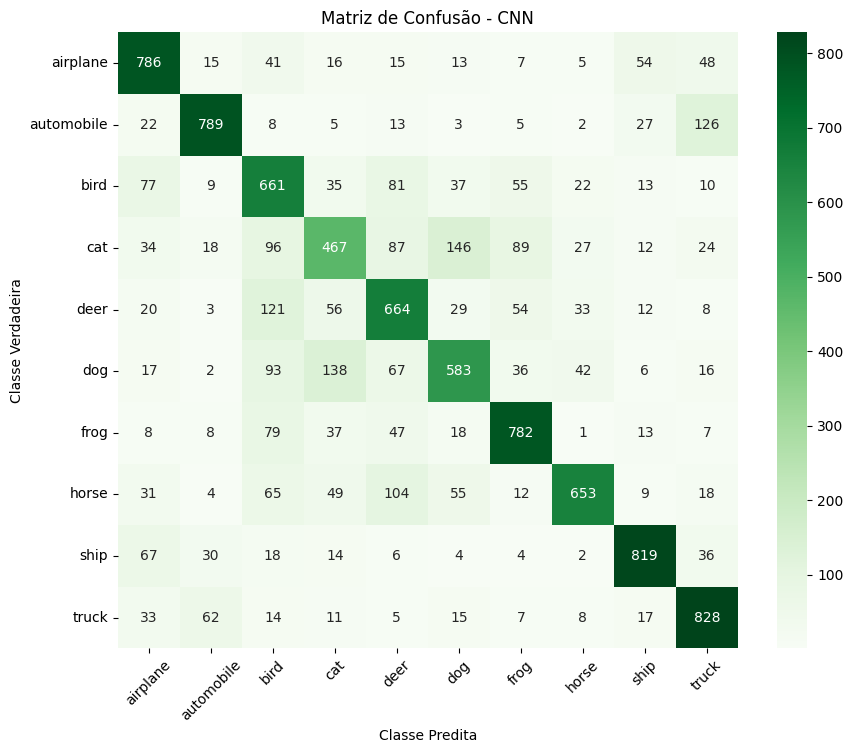

In [23]:
y_pred_probs_cnn = model_cnn.predict(x_test)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de Confusão - CNN")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

A matriz da CNN mostra mais acertos que a MLP, principalmente em classes como automobile, frog, ship e truck. As confusões diminuíram, embora ainda apareçam erros entre classes parecidas, como cat e dog, bird e deer, e deer e horse. Isso acontece porque a CNN consegue analisar melhor partes locais da imagem, enquanto a MLP perde essa organização ao transformar tudo em vetor.


### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

In [24]:
model_cnn_dropout = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_dropout = model_cnn_dropout.fit(
    x_train,
    y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4090 - loss: 1.6211 - val_accuracy: 0.5569 - val_loss: 1.2731
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5585 - loss: 1.2454 - val_accuracy: 0.6165 - val_loss: 1.1140
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6161 - loss: 1.0955 - val_accuracy: 0.6670 - val_loss: 0.9656
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6503 - loss: 0.9993 - val_accuracy: 0.6863 - val_loss: 0.9167
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6744 - loss: 0.9314 - val_accuracy: 0.7118 - val_loss: 0.8494
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6931 - loss: 0.8837 - val_accuracy: 0.7205 - val_loss: 0.8130
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7061 - loss: 0.8432 - val_accuracy: 0.7327 - val_loss: 0.7825
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7179 - loss: 0.8057 - val_accuracy: 

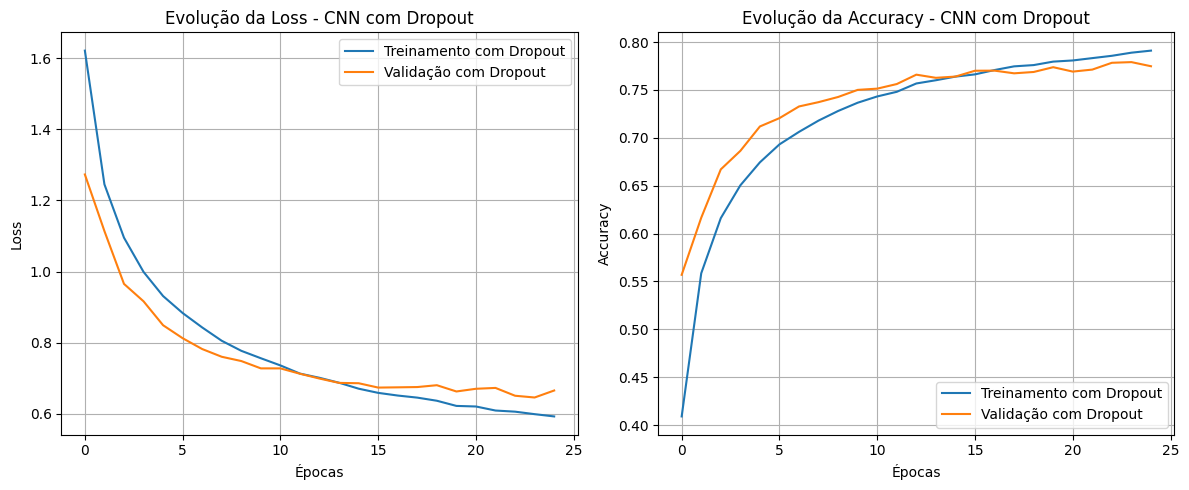

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn_dropout.history['loss'], label='Treinamento com Dropout')
plt.plot(history_cnn_dropout.history['val_loss'], label='Validação com Dropout')
plt.title('Evolução da Loss - CNN com Dropout')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn_dropout.history['accuracy'], label='Treinamento com Dropout')
plt.plot(history_cnn_dropout.history['val_accuracy'], label='Validação com Dropout')
plt.title('Evolução da Accuracy - CNN com Dropout')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
print("CNN original:")
print(f"Treino accuracy: {history_cnn.history['accuracy'][-1]:.4f}")
print(f"Validação accuracy: {history_cnn.history['val_accuracy'][-1]:.4f}")
print(f"Treino loss: {history_cnn.history['loss'][-1]:.4f}")
print(f"Validação loss: {history_cnn.history['val_loss'][-1]:.4f}")

print("\nCNN com Dropout:")
print(f"Treino accuracy: {history_cnn_dropout.history['accuracy'][-1]:.4f}")
print(f"Validação accuracy: {history_cnn_dropout.history['val_accuracy'][-1]:.4f}")
print(f"Treino loss: {history_cnn_dropout.history['loss'][-1]:.4f}")
print(f"Validação loss: {history_cnn_dropout.history['val_loss'][-1]:.4f}")

CNN original:
Treino accuracy: 0.9447
Validação accuracy: 0.7032
Treino loss: 0.1524
Validação loss: 1.7654

CNN com Dropout:
Treino accuracy: 0.7910
Validação accuracy: 0.7747
Treino loss: 0.5931
Validação loss: 0.6660


Com a adição do Dropout, o treinamento ficou mais equilibrado. A CNN original teve desempenho muito alto no treino, mas pior na validação, indicando overfitting. Já a CNN com Dropout apresentou curvas de treino e validação mais próximas, com menor diferença entre elas.

Isso mostra que o Dropout ajudou a reduzir a memorização dos dados de treinamento, forçando a rede a aprender padrões mais gerais. Mesmo que o desempenho no treino tenha ficado menor, a validação melhorou, indicando melhor capacidade de generalização. Portanto, o Dropout teve impacto positivo no controle do overfitting.


### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

A MLP e a CNN apresentaram comportamentos bem diferentes na classificação das imagens do CIFAR-10. A MLP é mais simples de implementar, mas não é tão adequada para imagens, pois transforma cada imagem em um vetor e perde a organização original dos pixels. Com isso, ela tem mais dificuldade para reconhecer padrões visuais e acaba confundindo mais classes parecidas.

A CNN foi mais eficiente porque trabalha diretamente com a imagem em seu formato original, analisando pequenas regiões e aprendendo características importantes para a classificação. Mesmo tendo menos parâmetros que a MLP, ela obteve melhor desempenho e maior capacidade de generalização. A matriz de confusão também mostrou que a CNN reduziu vários erros entre classes semelhantes.

Além disso, a CNN com Dropout apresentou um treinamento mais equilibrado, reduzindo o overfitting observado na CNN original. Assim, os resultados mostram que a MLP pode ser usada como modelo inicial, mas a CNN é mais apropriada para problemas de visão computacional, pois aproveita melhor as informações visuais das imagens e tende a alcançar resultados superiores.
